In [2]:
!pip install geopandas shapely fiona pyproj rtree

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 25.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   -------------- ------------------------- 9.2/24.5 MB 43.9 MB/s eta 0:00:01
   -------------------------- ------------- 16.0/24.5 MB 38.7 MB/s eta 0:00:01
   ------------------------------------- -- 23.1/24.5 MB 37.4 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.5 MB 35.9 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.5 MB 35.9 MB/s eta 0:00:01
   ---------------------------------------- 24.5/24.5 MB 22.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.1 MB ? eta -:--:--
   ---------------------------------------  6.0/6.1 MB 33.5 MB/s eta 0:00:01
   ---------------------------------------  6.0/6.1 MB 33.5 MB/s eta 0:00:01
   ---------------------------------------- 6.1/6.1 MB 11.7 MB/s eta 0:00:00
   --------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\ianmc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# Setup

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# Set display options
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [2]:
# ============================
# 1. GLOBAL CRIME / SAFETY DATA (COUNTRY LEVEL)
# ============================

# Load global country-level crime/safety data
global_path = "../data/crime-rate-by-country-2024.csv"  # from https://www.kaggle.com/datasets/shahriarkabir/crime-rate-by-country-2024?resource=download
global_df = pd.read_csv(global_path)

global_df.head()

,country,crimeRateByCountry_crimeIndex,CrimeRate_OverallCriminalityScoreGOCI,CrimeRate_CriminalMarketsScore,CrimeRate_CriminalActorsScore,CrimeRate_ResilienceScore,CrimeRateSafetyIndex
0,India,44.4,5.75,6.70,4.8,5.42,55.6
1,China,60.8,6.37,6.53,6.2,5.67,39.2
2,United States,49.2,5.67,5.83,5.5,7.13,50.8
3,Indonesia,45.9,6.85,6.60,7.1,4.25,54.1
4,Pakistan,42.8,6.03,6.27,5.8,3.96,57.2


In [3]:
print(global_df.columns)

Index(['country', 'crimeRateByCountry_crimeIndex', 'CrimeRate_OverallCriminalityScoreGOCI',
       'CrimeRate_CriminalMarketsScore', 'CrimeRate_CriminalActorsScore', 'CrimeRate_ResilienceScore',
       'CrimeRateSafetyIndex'],
      dtype='object')


In [4]:
# Basic info and cleaning

global_df.info()
global_df.describe(include="all")

# Standardize column names
global_df.columns = (
    global_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Rename to a cleaner schema

global_df = global_df.rename(columns={
    "country_name": "country",
    "crimeratebycountry_crimeindex": "crime_index",
    "crimerate_overallcriminalityscoregoci": "overall_criminality_score",
    "crimerate_criminalmarketsscore": "criminal_markets_score",
    "crimerate_criminalactorsscore": "criminal_actors_score",
    "crimerate_resiliencescore": "resilience_score",
    "crimeratesafetyindex": "safety_index"
})

global_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 7 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   country                                198 non-null    object 
 1   crimeRateByCountry_crimeIndex          141 non-null    float64
 2   CrimeRate_OverallCriminalityScoreGOCI  192 non-null    float64
 3   CrimeRate_CriminalMarketsScore         192 non-null    float64
 4   CrimeRate_CriminalActorsScore          192 non-null    float64
 5   CrimeRate_ResilienceScore              192 non-null    float64
 6   CrimeRateSafetyIndex                   140 non-null    float64
dtypes: float64(6), object(1)
memory usage: 11.0+ KB


,country,crime_index,overall_criminality_score,criminal_markets_score,criminal_actors_score,resilience_score,safety_index
0,India,44.4,5.75,6.70,4.8,5.42,55.6
1,China,60.8,6.37,6.53,6.2,5.67,39.2
2,United States,49.2,5.67,5.83,5.5,7.13,50.8
3,Indonesia,45.9,6.85,6.60,7.1,4.25,54.1
4,Pakistan,42.8,6.03,6.27,5.8,3.96,57.2


In [5]:
# Basic cleaning

# Drop exact duplicates
global_df = global_df.drop_duplicates()

# Check missing values
global_df.isna().sum()

# Drop rows with missing country or crime_index
global_df = global_df.dropna(subset=["country", "crime_index"])

# Convert numeric columns
num_cols = [
    "crime_index",
    "overall_criminality_score",
    "criminal_markets_score",
    "criminal_actors_score",
    "resilience_score",
    "safety_index"
]
for col in num_cols:
    global_df[col] = pd.to_numeric(global_df[col], errors="coerce")

global_df.describe()


,crime_index,overall_criminality_score,criminal_markets_score,criminal_actors_score,resilience_score,safety_index
count,141.000000,135.000000,135.000000,135.000000,135.000000,140.000000
mean,45.768774,5.338296,5.204667,5.471111,5.016074,54.237143
std,15.200526,1.178399,1.150262,1.347350,1.655917,15.254943
min,14.300000,2.580000,1.670000,2.400000,1.500000,17.900000
25%,32.800000,4.475000,4.450000,4.550000,3.960000,43.900000
50%,46.500000,5.200000,5.170000,5.500000,5.130000,53.500000
75%,55.900000,6.220000,6.030000,6.600000,5.940000,67.250000
max,82.100000,8.150000,8.130000,8.600000,8.630000,85.700000


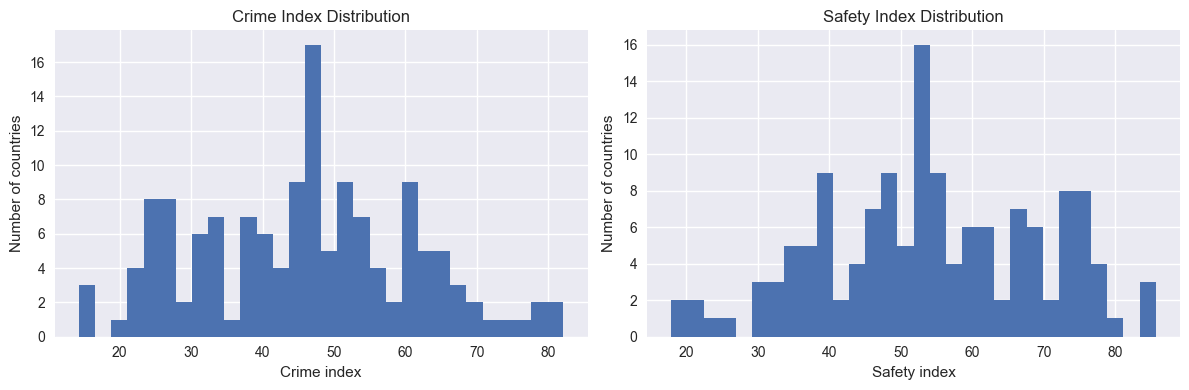

In [6]:
# Simple EDA plots

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
global_df["crime_index"].hist(bins=30, ax=ax[0])
ax[0].set_title("Crime Index Distribution")
ax[0].set_xlabel("Crime index")
ax[0].set_ylabel("Number of countries")

global_df["safety_index"].hist(bins=30, ax=ax[1])
ax[1].set_title("Safety Index Distribution")
ax[1].set_xlabel("Safety index")
ax[1].set_ylabel("Number of countries")

plt.tight_layout()
plt.show()

In [7]:
# Top / bottom countries by crime_index

print("Top 10 highest crime index:")
display(global_df.sort_values("crime_index", ascending=False).head(10))

print("Top 10 lowest crime index:")
display(global_df.sort_values("crime_index", ascending=True).head(10))

Top 10 highest crime index:


,country,crime_index,overall_criminality_score,criminal_markets_score,criminal_actors_score,resilience_score,safety_index
52,Venezuela,82.1,6.72,6.03,7.4,1.88,17.9
91,Papua New Guinea,80.4,5.72,5.33,6.1,3.29,19.6
35,Afghanistan,78.4,7.10,7.00,7.2,1.50,21.6
81,Haiti,78.3,5.93,5.77,6.1,2.46,21.7
23,South Africa,75.5,7.18,6.87,7.5,5.63,24.5
87,Honduras,74.3,7.05,6.00,8.1,4.08,25.7
152,Trinidad and Tobago,70.8,5.20,4.80,5.6,5.33,29.2
56,Syria,69.1,7.07,6.43,7.7,1.92,30.9
161,Guyana,68.8,5.97,5.13,6.8,4.04,31.2
46,Peru,67.5,6.40,6.20,6.6,4.38,32.5


Top 10 lowest crime index:


,country,crime_index,overall_criminality_score,criminal_markets_score,criminal_actors_score,resilience_score,safety_index
136,Qatar,14.3,5.45,5.70,5.2,5.42,85.7
85,United Arab Emirates,14.6,6.37,7.03,5.7,5.13,85.4
59,Taiwan,16.1,NaN,NaN,NaN,NaN,83.9
122,Oman,19.6,4.40,4.90,3.9,5.21,80.4
139,Armenia,21.6,2.82,2.93,2.7,5.71,78.4
104,Hong Kong,21.7,NaN,NaN,NaN,NaN,78.3
11,Japan,22.9,4.28,3.87,4.7,7.38,77.1
114,Singapore,23.1,3.47,3.93,3.0,7.83,76.9
151,Bahrain,24.2,4.95,5.40,4.5,5.42,75.8
147,Slovenia,24.2,4.37,4.03,4.7,6.04,75.8


In [8]:
import geopandas as gpd

# Use a hosted world countries GeoJSON (no local download needed)
world_url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"

world = gpd.read_file(world_url)
world.head()

,id,name,geometry
0,AFG,Afghanistan,"POLYGON ((61.21082 35.65007, 62.23065 35.27066..."
1,AGO,Angola,"MULTIPOLYGON (((16.32653 -5.87747, 16.57318 -6..."
2,ALB,Albania,"POLYGON ((20.59025 41.8554, 20.46318 41.51509,..."
3,ARE,United Arab Emirates,"POLYGON ((51.57952 24.2455, 51.75744 24.29407,..."
4,ARG,Argentina,"MULTIPOLYGON (((-65.5 -55.2, -66.45 -55.25, -6..."


In [9]:
# Normalize names to improve matching
global_df["country_norm"] = global_df["country"].str.strip().str.lower()
world["country_norm"] = world["name"].str.strip().str.lower()

global_geo = world.merge(
    global_df,
    on="country_norm",
    how="left",
    suffixes=("_world", "")
)

# Check how many got matched
matched = global_geo["crime_index"].notna().sum()
total = len(global_df)
print(f"Matched {matched} of {total} countries")

global_geo.head()


Matched 126 of 141 countries


,id,name,geometry,country_norm,country,crime_index,overall_criminality_score,criminal_markets_score,criminal_actors_score,resilience_score,safety_index
0,AFG,Afghanistan,"POLYGON ((61.21082 35.65007, 62.23065 35.27066...",afghanistan,Afghanistan,78.4,7.10,7.00,7.2,1.50,21.6
1,AGO,Angola,"MULTIPOLYGON (((16.32653 -5.87747, 16.57318 -6...",angola,Angola,65.8,5.58,5.17,6.0,4.50,34.2
2,ALB,Albania,"POLYGON ((20.59025 41.8554, 20.46318 41.51509,...",albania,Albania,45.4,5.17,4.83,5.5,5.13,54.6
3,ARE,United Arab Emirates,"POLYGON ((51.57952 24.2455, 51.75744 24.29407,...",united arab emirates,United Arab Emirates,14.6,6.37,7.03,5.7,5.13,85.4
4,ARG,Argentina,"MULTIPOLYGON (((-65.5 -55.2, -66.45 -55.25, -6...",argentina,Argentina,64.0,5.00,4.50,5.5,5.96,36.0


### fixing unmatched countries 

In [10]:
# Countries that did NOT match any geometry
unmatched = global_df[~global_df["country_norm"].isin(global_geo["country_norm"])]
print("Unmatched countries in crime dataset:", len(unmatched))
unmatched[["country"]].drop_duplicates().sort_values("country").head(50)


Unmatched countries in crime dataset: 15


,country
172,Bahamas
151,Bahrain
175,Barbados
104,Hong Kong
168,Maldives
156,Mauritius
191,Monaco
150,North Macedonia
120,Palestine
110,Serbia


In [11]:
# Normalize your country names
global_df["country_norm"] = global_df["country"].str.strip().str.lower()

# Drop pseudo rows / things you don't want at country level
drop_names = ["total", "hong kong"]
global_df = global_df[~global_df["country_norm"].isin(drop_names)].copy()

# Manual mapping from your CSV names -> world names (in lower case)
name_fix = {
    # exact unmatched from your screenshot
    "bahamas": "the bahamas",
    "bahrain": "bahrain",
    "barbados": "barbados",
    "maldives": "maldives",              # not in this world file, will stay unmatched (tiny island)
    "mauritius": "mauritius",           # same as above
    "monaco": "monaco",                 # same as above
    "palestine": "west bank",           # world uses 'West Bank'
    "serbia": "republic of serbia",     # world uses 'Republic of Serbia'
    "singapore": "singapore",           # not present in this world file, stays unmatched
    "tanzania": "united republic of tanzania",
    "united states": "united states of america",
    "united states virgin islands": "puerto rico", # rough proxy: world has Puerto Rico, not USVI
    "canada":"Canada",
}


# Apply mapping to a fixed normalized name
global_df["country_norm_fixed"] = global_df["country_norm"].replace(
    {k: v.lower() for k, v in name_fix.items()}
)

# For all others, if not in mapping, keep original normalized name
global_df.loc[~global_df["country_norm"].isin(name_fix.keys()), "country_norm_fixed"] = \
    global_df.loc[~global_df["country_norm"].isin(name_fix.keys()), "country_norm"]

# Normalize world names
world["country_norm_fixed"] = world["name"].str.strip().str.lower()

# Merge
global_geo = world.merge(
    global_df,
    on="country_norm_fixed",
    how="left",
    suffixes=("_world", "")
)

matched = global_geo["crime_index"].notna().sum()
total = len(global_df)
print(f"Matched {matched} of {total} countries after fixes")

Matched 132 of 139 countries after fixes


In [12]:
unmatched = global_df[~global_df["country_norm_fixed"].isin(global_geo["country_norm_fixed"])]
unmatched[["country"]].drop_duplicates().sort_values("country")

,country
151,Bahrain
175,Barbados
168,Maldives
156,Mauritius
191,Monaco
150,North Macedonia
114,Singapore


In [13]:
global_df[global_df["country"].str.contains("C")]

,country,crime_index,overall_criminality_score,criminal_markets_score,criminal_actors_score,resilience_score,safety_index,country_norm,country_norm_fixed
1,China,60.8,6.37,6.53,6.2,5.67,39.2,china,china
49,Ivory Coast,57.5,6.02,5.93,6.1,5.13,42.5,ivory coast,ivory coast
64,Chad,58.7,5.50,5.10,5.9,2.42,41.3,chad,chad
65,Chile,25.8,5.18,5.07,5.3,6.17,74.2,chile,chile
72,Cambodia,44.8,6.85,6.70,7.0,3.63,55.2,cambodia,cambodia
86,Cuba,32.2,3.37,3.63,3.1,5.38,67.8,cuba,cuba
88,Czech Republic,26.8,4.68,4.87,4.5,6.42,73.2,czech republic,czech republic
126,Costa Rica,53.7,5.53,5.37,5.7,5.63,46.3,costa rica,costa rica
129,Croatia,26.1,5.15,4.90,5.4,5.92,73.9,croatia,croatia
155,Cyprus,32.6,4.43,3.97,4.9,4.46,67.4,cyprus,cyprus


In [14]:
global_geo[global_geo["name"] == "Canada"][["name", "crime_index"]]

,name,crime_index
28,Canada,NaN


In [15]:
world["name"].sort_values().unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antarctica',
       'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan',
       'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda',
       'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana',
       'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cambodia', 'Cameroon', 'Canada', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia',
       'Cuba', 'Cyprus', 'Czech Republic',
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Ethiopia', 'Falkland Islands', 'Fiji', 'Finland', 'France',
       'French Guiana', 'French Southern and Antarctic Lands', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Greenland',
       'Guatemala', 'Guinea', 'Guinea Bissau', 'Guyana', 'Haiti',
     

### Start of Heat Maps and end of Matching fix 

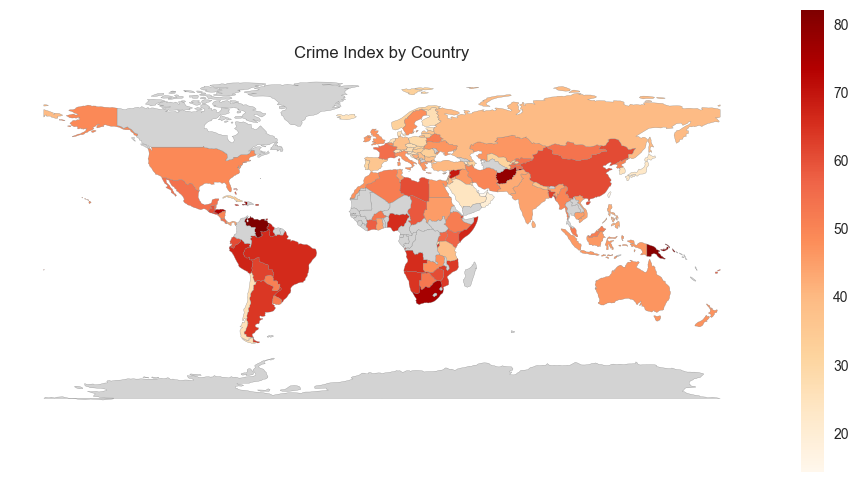

In [16]:
# 2.4 Choropleth map for crime_index

fig, ax = plt.subplots(figsize=(12, 6))
global_geo.plot(
    column="crime_index",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
ax.set_title("Crime Index by Country")
ax.axis("off")
plt.show()


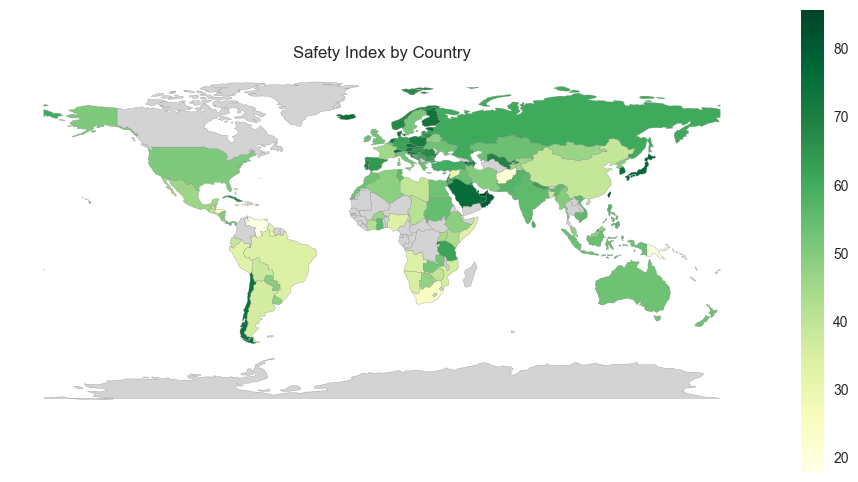

In [17]:
# 2.5 Choropleth map for safety_index

fig, ax = plt.subplots(figsize=(12, 6))
global_geo.plot(
    column="safety_index",
    cmap="YlGn",
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
ax.set_title("Safety Index by Country")
ax.axis("off")
plt.show()


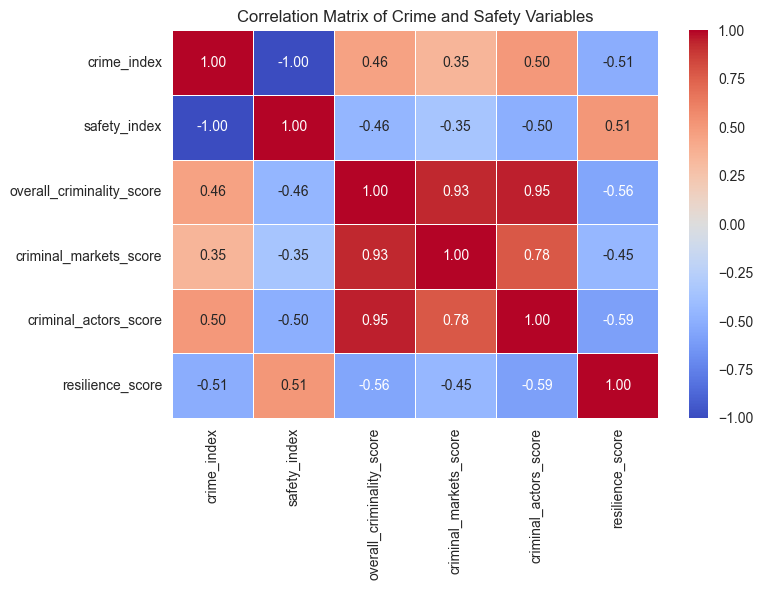

In [31]:
import seaborn as sns

corr_cols = [
    "crime_index",
    "safety_index",
    "overall_criminality_score",
    "criminal_markets_score",
    "criminal_actors_score",
    "resilience_score",
]

corr_matrix = global_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Correlation Matrix of Crime and Safety Variables")
plt.tight_layout()
plt.show()

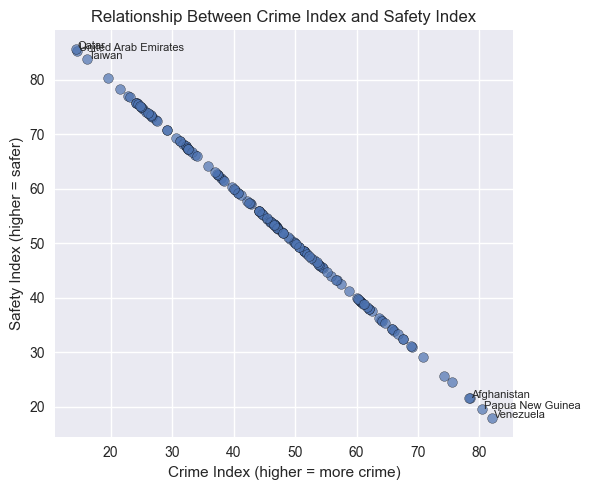

In [32]:
plt.figure(figsize=(6, 5))
plt.scatter(
    global_df["crime_index"],
    global_df["safety_index"],
    alpha=0.7,
    edgecolor="k"
)
plt.xlabel("Crime Index (higher = more crime)")
plt.ylabel("Safety Index (higher = safer)")
plt.title("Relationship Between Crime Index and Safety Index")

# Optional: annotate a few extreme countries
for _, row in global_df.nlargest(3, "crime_index").iterrows():
    plt.text(row["crime_index"] + 0.3, row["safety_index"], row["country"], fontsize=8)
for _, row in global_df.nsmallest(3, "crime_index").iterrows():
    plt.text(row["crime_index"] + 0.3, row["safety_index"], row["country"], fontsize=8)

plt.tight_layout()
plt.show()


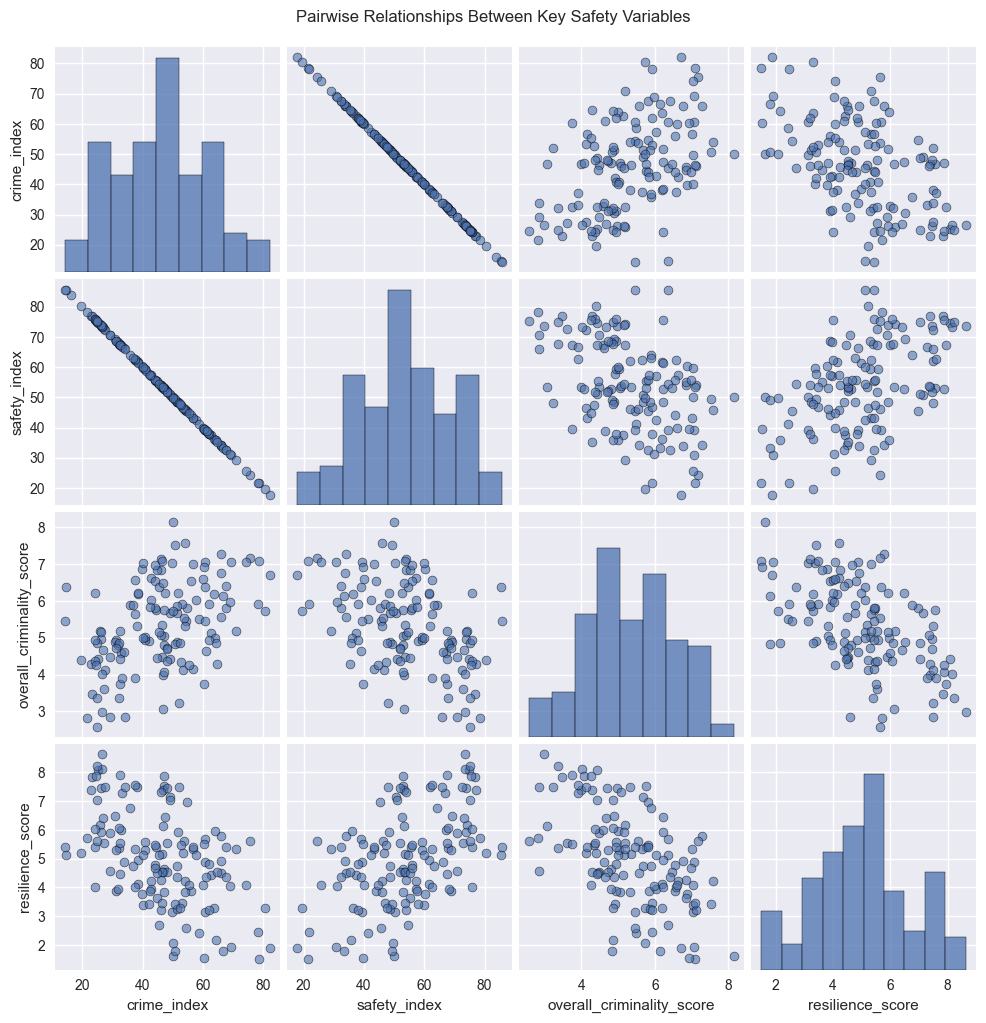

In [33]:
sns.pairplot(
    global_df[
        ["crime_index",
         "safety_index",
         "overall_criminality_score",
         "resilience_score"]
    ],
    diag_kind="hist",
    plot_kws={"alpha": 0.6, "edgecolor": "k", "s": 40}
)
plt.suptitle("Pairwise Relationships Between Key Safety Variables", y=1.02)
plt.show()


In [34]:
# Create a categorical safety level based on safety_index quartiles
global_df["safety_level"] = pd.qcut(
    global_df["safety_index"],
    q=4,
    labels=["Low", "Medium", "High", "Very high"]
)


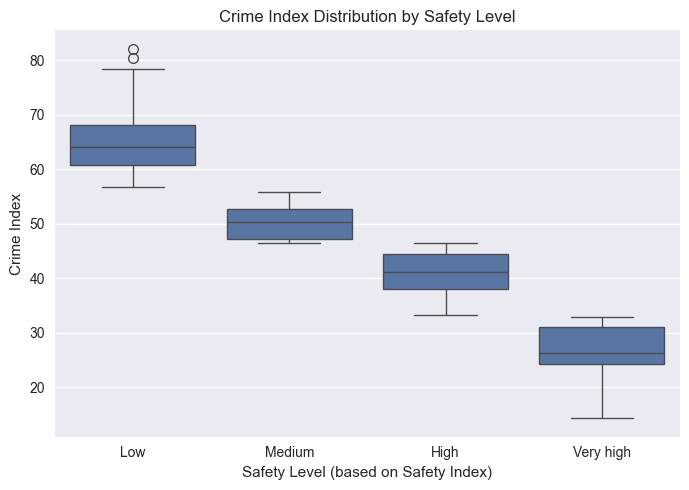

In [35]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=global_df,
    x="safety_level",
    y="crime_index",
    order=["Low", "Medium", "High", "Very high"]
)
plt.xlabel("Safety Level (based on Safety Index)")
plt.ylabel("Crime Index")
plt.title("Crime Index Distribution by Safety Level")
plt.tight_layout()
plt.show()


In [18]:
# ============================
# 2. PUERTO RICO CRIME DATASETS  (Exact crime/adress and regional (need to find regional))
# ============================

# 2.1 Load raw Puerto Rico crime dataset
pr_path = "data/Feature Table (Incidencia Año Actual).csv"  # from https://incidenciacriminal.policia.pr.gov/publica/en
pr_df = pd.read_csv(pr_path)

pr_df.head()


,Addr_type,KeyField,Street,Zone,Direccion Estandarizada,Estructura,Fecha Ocurrencia,Delito NIBRS,Delito Tipo I,Hora Ocurrencia,Dia de la semana,km,Match_addr,Match_type,Carretera,OBJECTID,observaciones hechos,created_user,created_date,last_edited_user,last_edited_date
0,NaN,NaN,NaN,NaN,CARR KM,COMANDANCIA AREA AIBONITO,1/7/2026,13C - Intimidation,Other,11:33:03,Wednesday,0.0,NaN,A,NaN,1862942,NaN,SYNCCOMANDANCIA,1/8/2026,SYNCCOMANDANCIA,1/8/2026
1,NaN,NaN,NaN,NaN,CARR KM,BARRIO PARCELAS FALU 145 CALLE 41 SAN JUAN PR ...,1/8/2026,26A - False Pretenses / Swindle / Confidence Game,Other,04:08:41,Thursday,0.0,145 Calle 41 172,A,NaN,1862975,NaN,SYNCCOMANDANCIA,1/8/2026,SYNCCOMANDANCIA,1/8/2026
2,NaN,NaN,NaN,NaN,920,CONDOMINIO VISTA SERENA,1/7/2026,23G - Theft of Motor Vehicle Parts or Accessories,Theft,14:30:00,Wednesday,9.2,CONDOMINIO VISTA SERENA,A,175,1862989,NaN,SYNCCOMANDANCIA,1/8/2026,SYNCCOMANDANCIA,1/8/2026
3,NaN,NaN,NaN,NaN,5 CALLE A,BARRIO CAMPO RICO,1/7/2026,290 - Damage / Destruction / Vandalism,Other,18:52:00,Wednesday,0.0,x=256955.905512 y=256360.629921,PP,NaN,1862992,NaN,SYNCCOMANDANCIA,1/8/2026,IDVALENTIN,1/11/2026
4,NaN,NaN,NaN,NaN,AL11 CALLE 35,URBANIZACION VILLAS DE LOIZA,1/5/2026,26A - False Pretenses / Swindle / Confidence Game,Other,14:40:00,Monday,0.0,x=259918.897638 y=261414.960630,PP,NaN,1862993,NaN,SYNCCOMANDANCIA,1/8/2026,IDVALENTIN,1/11/2026


In [19]:
print(pr_df.columns)

Index(['Addr_type', 'KeyField', 'Street', 'Zone', 'Direccion Estandarizada', 'Estructura', 'Fecha Ocurrencia',
       'Delito NIBRS', 'Delito Tipo I', 'Hora Ocurrencia', 'Dia de la semana', 'km', 'Match_addr', 'Match_type',
       'Carretera', 'OBJECTID', 'observaciones hechos', 'created_user', 'created_date', 'last_edited_user',
       'last_edited_date'],
      dtype='object')


In [20]:
# Standardize column names
pr_df.columns = (
    pr_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

pr_df.head()

,addr_type,keyfield,street,zone,direccion_estandarizada,estructura,fecha_ocurrencia,delito_nibrs,delito_tipo_i,hora_ocurrencia,dia_de_la_semana,km,match_addr,match_type,carretera,objectid,observaciones_hechos,created_user,created_date,last_edited_user,last_edited_date
0,NaN,NaN,NaN,NaN,CARR KM,COMANDANCIA AREA AIBONITO,1/7/2026,13C - Intimidation,Other,11:33:03,Wednesday,0.0,NaN,A,NaN,1862942,NaN,SYNCCOMANDANCIA,1/8/2026,SYNCCOMANDANCIA,1/8/2026
1,NaN,NaN,NaN,NaN,CARR KM,BARRIO PARCELAS FALU 145 CALLE 41 SAN JUAN PR ...,1/8/2026,26A - False Pretenses / Swindle / Confidence Game,Other,04:08:41,Thursday,0.0,145 Calle 41 172,A,NaN,1862975,NaN,SYNCCOMANDANCIA,1/8/2026,SYNCCOMANDANCIA,1/8/2026
2,NaN,NaN,NaN,NaN,920,CONDOMINIO VISTA SERENA,1/7/2026,23G - Theft of Motor Vehicle Parts or Accessories,Theft,14:30:00,Wednesday,9.2,CONDOMINIO VISTA SERENA,A,175,1862989,NaN,SYNCCOMANDANCIA,1/8/2026,SYNCCOMANDANCIA,1/8/2026
3,NaN,NaN,NaN,NaN,5 CALLE A,BARRIO CAMPO RICO,1/7/2026,290 - Damage / Destruction / Vandalism,Other,18:52:00,Wednesday,0.0,x=256955.905512 y=256360.629921,PP,NaN,1862992,NaN,SYNCCOMANDANCIA,1/8/2026,IDVALENTIN,1/11/2026
4,NaN,NaN,NaN,NaN,AL11 CALLE 35,URBANIZACION VILLAS DE LOIZA,1/5/2026,26A - False Pretenses / Swindle / Confidence Game,Other,14:40:00,Monday,0.0,x=259918.897638 y=261414.960630,PP,NaN,1862993,NaN,SYNCCOMANDANCIA,1/8/2026,IDVALENTIN,1/11/2026


In [21]:
# Check of key columns
[key for key in pr_df.columns if "fecha" in key or "delito" in key or "estructura" in key][:10]

['estructura', 'fecha_ocurrencia', 'delito_nibrs', 'delito_tipo_i']

In [22]:
# Parse date and extract year/month/weekday

# Adjust the column name if yours differs (e.g., 'fecha_ocurrencia')
date_col = "fecha_ocurrencia"

pr_df[date_col] = pd.to_datetime(pr_df[date_col], errors="coerce", dayfirst=False)

pr_df["year"] = pr_df[date_col].dt.year
pr_df["month"] = pr_df[date_col].dt.month
pr_df["weekday"] = pr_df[date_col].dt.day_name()

pr_df[["fecha_ocurrencia", "year", "month", "weekday"]].head()


,fecha_ocurrencia,year,month,weekday
0,2026-01-07,2026,1,Wednesday
1,2026-01-08,2026,1,Thursday
2,2026-01-07,2026,1,Wednesday
3,2026-01-07,2026,1,Wednesday
4,2026-01-05,2026,1,Monday


In [23]:
pr_df = pr_df[pr_df["year"].notna()].copy()

In [24]:
pr_df = pr_df.rename(columns={
    "direccion_estandarizada": "standardized_address",
    "estructura": "structure_name",
    "fecha_ocurrencia": "occurrence_date",
    "delito_nibrs": "offense_nibrs",
    "delito_tipo_i": "offense_type_i",
    "hora_ocurrencia": "occurrence_time",
    "dia_de_la_semana": "weekday_spanish",
    "carretera": "highway",
    "observaciones_hechos": "incident_notes",
})


In [25]:
pr_df.columns

Index(['addr_type', 'keyfield', 'street', 'zone', 'standardized_address', 'structure_name', 'occurrence_date',
       'offense_nibrs', 'offense_type_i', 'occurrence_time', 'weekday_spanish', 'km', 'match_addr', 'match_type',
       'highway', 'objectid', 'incident_notes', 'created_user', 'created_date', 'last_edited_user', 'last_edited_date',
       'year', 'month', 'weekday'],
      dtype='object')

In [26]:
pr_df.tail()

,addr_type,keyfield,street,zone,standardized_address,structure_name,occurrence_date,offense_nibrs,offense_type_i,occurrence_time,weekday_spanish,km,match_addr,match_type,highway,objectid,incident_notes,created_user,created_date,last_edited_user,last_edited_date,year,month,weekday
1995,NaN,ESTACIONAMIENTO COOPERATIVA NAGUABEÑA,CARRETERA 31,NaN,CARRETERA 31,ESTACIONAMIENTO COOPERATIVA NAGUABENA,2026-01-05,23F - Theft From Motor Vehicle,Theft,11:18:00,Monday,0.0,Carretera 31 4024,A,NaN,1862826,NaN,SYNCCOMANDANCIA,1/7/2026,SYNCCOMANDANCIA,1/7/2026,2026,1,Monday
1996,NaN,NaN,CARRETERA 3 KM 85,NaN,CARRETERA 3 KM 85,NaN,2026-01-05,90Z - All Other Offenses,Other,12:30:00,Monday,0.0,KM 85 PR-3 4019,A,NaN,1862855,NaN,SYNCCOMANDANCIA,1/7/2026,SYNCCOMANDANCIA,1/7/2026,2026,1,Monday
1997,NaN,NaN,NaN,NaN,62 SECTOR OBEN CALLE CEREZO,BARRIO CACAO BAJO,2026-01-04,09A - Murder and Nonnegligent Manslaughter,Murder,15:58:30,Sunday,0.0,x=245824.961750 y=217068.887699,PP,NaN,1862862,NaN,SYNCCOMANDANCIA,1/5/2026,YACOSTA,1/6/2026,2026,1,Sunday
1998,NaN,NaN,NaN,NaN,BARRIO PUEBLO LARES,EDIFICIO PRECINTO LARES,2026-01-05,13B - Simple Assault,Other,02:17:59,Tuesday,0.0,x=153058.681263 y=251300.594526,PP,NaN,1891413,NaN,SYNCCOMANDANCIA,1/8/2026,LQUINONES,1/8/2026,2026,1,Monday
1999,NaN,NaN,NaN,NaN,CALLE SAN GUILLERMO,CONDOMINIO JARDINES DE SAN INGNACIO,2026-01-11,11A - Rape,Rape,23:13:23,Sunday,0.0,Calle San Guillermo 150,A,NaN,1891542,NaN,SYNCCOMANDANCIA,1/12/2026,SYNCCOMANDANCIA,1/12/2026,2026,1,Sunday


In [27]:
# key: kwm6ph3bg2mp96qjkhhkf846

In [28]:
import requests
import pandas as pd

TUGO_API_KEY = "kwm6ph3bg2mp96qjkhhkf846"

url = "https://api.tugo.com/v1/travelsafe/countries"

headers = {
    "Content-Type": "application/x-www-form-urlencoded",
    "X-Auth-API-Key": TUGO_API_KEY,
}

resp = requests.get(url, headers=headers)
print(resp.status_code)
print(resp.text[:500])

503
<html>
<head><title>503 Service Temporarily Unavailable</title></head>
<body>
<center><h1>503 Service Temporarily Unavailable</h1></center>
</body>
</html>



In [29]:
import requests
import pandas as pd

TUGO_API_KEY = "kwm6ph3bg2mp96qjkhhkf846E"  
BASE_URL = "https://api.tugo.com/v1/travelsafe"

headers = {
    "x-api-key": TUGO_API_KEY
}

def get_tugo_country_advisory(country_code: str):
    """
    Fetch travel advisory and risk info for a given ISO2 country code,
    e.g., 'PR', 'MX', 'US'.
    Returns a small dict or None if not found.
    """
    url = f"{BASE_URL}/countries/{country_code}"
    r = requests.get(url, headers=headers)
    if r.status_code == 404:
        return None
    r.raise_for_status()
    data = r.json()
    
    # Adjust keys based on actual JSON (this follows TuGo docs pattern)
    risk = data.get("risk", {})  # {'level': 'Low', 'score': 2, ...}
    advisories = data.get("advisories", [])
    
    return {
        "country_code": country_code,
        "risk_level": risk.get("level"),
        "risk_score": risk.get("score"),
        "risk_trend": risk.get("trend"),
        "advisory_count": len(advisories),
    }

# Example: test for Puerto Rico, Mexico, US
for cc in ["PR", "MX", "US"]:
    print(cc, get_tugo_country_advisory(cc))


HTTPError: 403 Client Error: Forbidden for url: https://api.tugo.com/v1/travelsafe/countries/PR

In [ ]:
# Suppose global_df has an ISO2 code column called 'iso2'
# If not, you can manually define a small list:
country_codes = ["PR", "MX", "US", "CA", "BR", "DE", "FR"]

records = []
for cc in country_codes:
    rec = get_tugo_country_advisory(cc)
    if rec:
        records.append(rec)

tugo_df = pd.DataFrame(records)
tugo_df


In [ ]:
# Example merge
# global_df must have a matching iso2 code column
# e.g., global_df['country_code'] = ['PR','MX',...]
global_df = global_df.merge(
    tugo_df,
    left_on="country_code",
    right_on="country_code",
    how="left"
)

global_df.head()


In [ ]:
feature_cols = [
    "crime_index",
    "safety_index",
    "overall_criminality_score",
    "criminal_markets_score",
    "criminal_actors_score",
    "resilience_score",
    "risk_score",      # from TuGo
    "advisory_count",  # from TuGo
]

# Then build X, y and train your RandomForest / MLP as before


In [2]:
%pip install ipynbname

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\ianmc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import ipynbname

nb_path = ipynbname.path()
nb_name = nb_path.name 
nb_name


'ta_data.ipynb'

In [6]:
import sys
from pathlib import Path


# HTML
!"{sys.executable}" -m nbconvert --to html "{nb_name}"

[NbConvertApp] Converting notebook ta_data.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1163445 bytes to ta_data.html


In [7]:
# PDF 
!"{sys.executable}" -m nbconvert --to pdf "{nb_name}"

[NbConvertApp] Converting notebook ta_data.ipynb to pdf
[NbConvertApp] Support files will be in ta_data_files\
[NbConvertApp] Making directory .\ta_data_files
[NbConvertApp] Writing 131576 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | b had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 601749 bytes to ta_data.pdf
